In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import xgboost as xgb
import joblib

In [ ]:
# Load dataset
df = pd.read_csv('fire_incident.csv')
df.columns = [c.strip() for c in df.columns]

In [ ]:
df.head()

,Date,Year,Time,Day_of_Week,Barangay,Latitude,Longitude,Weather,Property_Type,Fire_Cause,Fire_Type,Fire_Severity,Casualty_Count,Response_Time,Fire_Duration
0,18/11/2021,2021,18:10,Thursday,I-C (Bagong Bayan),14.076365,121.310982,Sunny,Residential,Natural,Grass Fire,Medium,7,6,55
1,23/02/2023,2023,19:54,Thursday,Santa Veronica (Bae),14.068024,121.320271,Rainy,Residential,Cooking,Residential Fire,High,7,12,15
2,01/09/2021,2021,1:12,Wednesday,I-A (Sambat),14.072499,121.316021,Sunny,Residential,Electrical,Electrical Fire,Medium,2,11,41
3,16/08/2022,2022,2:10,Tuesday,VI-A (Mavenida),14.072298,121.330864,Stormy,Residential,Other,Other Fire,Medium,1,14,170
4,10/12/2024,2024,15:42,Tuesday,San Lucas 2 (Malinaw),14.063669,121.320900,Cloudy,Residential,Cooking,Residential Fire,High,11,9,64


In [ ]:
df.shape

(1000, 15)

In [ ]:
df.columns

Index(['Date', 'Year', 'Time', 'Day_of_Week', 'Barangay', 'Latitude',
       'Longitude', 'Weather', 'Property_Type', 'Fire_Cause', 'Fire_Type',
       'Fire_Severity', 'Casualty_Count', 'Response_Time', 'Fire_Duration'],
      dtype='object')

In [ ]:
# Define features and target
X = df[['Year', 'Barangay', 'Fire_Type', 'Fire_Cause']]
y = df['Casualty_Count'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Year']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Barangay', 'Fire_Type', 'Fire_Cause'])
    ]
)

In [ ]:
# XGBoost pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
])

In [ ]:
# XGBoost pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
])

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
# Train model
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Barangay', 'Fire_Type',
                                                   'Fire_Cause'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, devic...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
# Make predictions
y_pred = pipe.predict(X_test)

In [ ]:
print("=== XGBoost - Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

=== XGBoost - Classification Report ===
              precision    recall  f1-score   support

           0     0.0909    0.0119    0.0211        84
           1     0.7128    0.9537    0.8158       216

    accuracy                         0.6900       300
   macro avg     0.4019    0.4828    0.4184       300
weighted avg     0.5387    0.6900    0.5933       300



=== XGBoost - Confusion Matrix ===
[[  1  83]
 [ 10 206]]


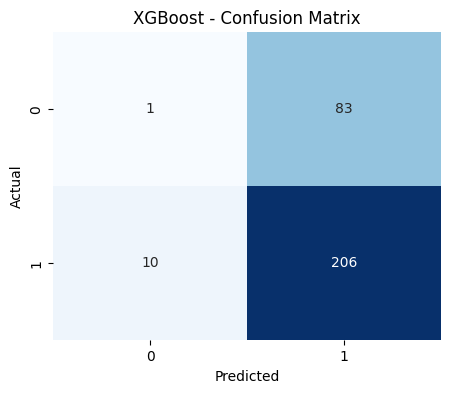

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("=== XGBoost - Confusion Matrix ===")
print(cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== XGBoost - ROC AUC: 0.5436 ===


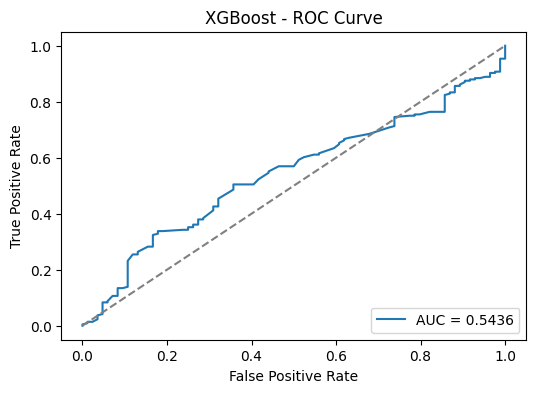

In [ ]:
# ROC Curve
y_proba = pipe.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(f"=== XGBoost - ROC AUC: {roc_auc:.4f} ===")
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost - ROC Curve")
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Save model
joblib.dump(pipe, "fire_predictor_xgb.pkl")
print("Saved model to fire_predictor_xgb.pkl")

Saved model to fire_predictor_xgb.pkl
